# 📊 Trader Behavior vs Market Sentiment Analysis

### Objective
Analyze how trader performance varies with market sentiment (Fear vs Greed) using historical trading data.

### Datasets Used
- Historical Trader Data
- Bitcoin Fear & Greed Index

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# better visuals
sns.set(style="whitegrid")

In [44]:
import sys
import os

# Add project root directory to path
sys.path.append(os.path.abspath(".."))

In [7]:
trader_df = pd.read_csv("../data/historical_data.csv")
sentiment_df = pd.read_csv("../data/fear_greed_index.csv")

In [8]:
trader_df.columns = trader_df.columns.str.strip().str.lower()
sentiment_df.columns = sentiment_df.columns.str.strip().str.lower()

In [9]:
print("=== TRADER COLUMNS ===")
print(trader_df.columns)

print("\n=== SENTIMENT COLUMNS ===")
print(sentiment_df.columns)

=== TRADER COLUMNS ===
Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')

=== SENTIMENT COLUMNS ===
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [10]:
display(trader_df.head())
display(sentiment_df.head())

,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [11]:
print("TRADER INFO")
trader_df.info()

print("\nSENTIMENT INFO")
sentiment_df.info()

TRADER INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   account           211224 non-null  object 
 1   coin              211224 non-null  object 
 2   execution price   211224 non-null  float64
 3   size tokens       211224 non-null  float64
 4   size usd          211224 non-null  float64
 5   side              211224 non-null  object 
 6   timestamp ist     211224 non-null  object 
 7   start position    211224 non-null  float64
 8   direction         211224 non-null  object 
 9   closed pnl        211224 non-null  float64
 10  transaction hash  211224 non-null  object 
 11  order id          211224 non-null  int64  
 12  crossed           211224 non-null  bool   
 13  fee               211224 non-null  float64
 14  trade id          211224 non-null  float64
 15  timestamp         211224 non-null  float64
dtypes: bool(

In [12]:
print("Missing Values (Trader):")
print(trader_df.isnull().sum())

print("\nMissing Values (Sentiment):")
print(sentiment_df.isnull().sum())

Missing Values (Trader):
account             0
coin                0
execution price     0
size tokens         0
size usd            0
side                0
timestamp ist       0
start position      0
direction           0
closed pnl          0
transaction hash    0
order id            0
crossed             0
fee                 0
trade id            0
timestamp           0
dtype: int64

Missing Values (Sentiment):
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [13]:
print("\nChecking possible columns...")

for col in trader_df.columns:
    print(f"\nColumn: {col}")
    print(trader_df[col].head())


Checking possible columns...

Column: account
0    0xae5eacaf9c6b9111fd53034a602c192a04e082ed
1    0xae5eacaf9c6b9111fd53034a602c192a04e082ed
2    0xae5eacaf9c6b9111fd53034a602c192a04e082ed
3    0xae5eacaf9c6b9111fd53034a602c192a04e082ed
4    0xae5eacaf9c6b9111fd53034a602c192a04e082ed
Name: account, dtype: object

Column: coin
0    @107
1    @107
2    @107
3    @107
4    @107
Name: coin, dtype: object

Column: execution price
0    7.9769
1    7.9800
2    7.9855
3    7.9874
4    7.9894
Name: execution price, dtype: float64

Column: size tokens
0    986.87
1     16.00
2    144.09
3    142.98
4      8.73
Name: size tokens, dtype: float64

Column: size usd
0    7872.16
1     127.68
2    1150.63
3    1142.04
4      69.75
Name: size usd, dtype: float64

Column: side
0    BUY
1    BUY
2    BUY
3    BUY
4    BUY
Name: side, dtype: object

Column: timestamp ist
0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: timestamp ist, dty

In [15]:
# Try to detect time column automatically
possible_time_cols = ['time', 'timestamp', 'datetime', 'created_at', 'execution_time']

time_col = None
for col in possible_time_cols:
    if col in trader_df.columns:
        time_col = col
        break

print("Detected time column:", time_col)

Detected time column: timestamp


In [16]:
trader_df[time_col] = pd.to_datetime(trader_df[time_col], errors='coerce')

In [17]:
trader_df['date'] = trader_df[time_col].dt.date

In [18]:
print(sentiment_df.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [19]:
# usually 'date' or 'date'
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], errors='coerce')
sentiment_df['date'] = sentiment_df['date'].dt.date

In [20]:
trader_df = trader_df.dropna(subset=['date'])
sentiment_df = sentiment_df.dropna(subset=['date'])

In [21]:
# Convert timestamp column
trader_df['timestamp'] = pd.to_datetime(trader_df['timestamp'], errors='coerce')

# Extract date
trader_df['date'] = trader_df['timestamp'].dt.date

In [22]:
# Convert sentiment date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], errors='coerce')
sentiment_df['date'] = sentiment_df['date'].dt.date

In [23]:
trader_df = trader_df.dropna(subset=['date'])
sentiment_df = sentiment_df.dropna(subset=['date'])

In [24]:
print(trader_df[['timestamp', 'date']].head())
print(sentiment_df[['date']].head())

            timestamp        date
0 1970-01-01 00:28:50  1970-01-01
1 1970-01-01 00:28:50  1970-01-01
2 1970-01-01 00:28:50  1970-01-01
3 1970-01-01 00:28:50  1970-01-01
4 1970-01-01 00:28:50  1970-01-01
         date
0  2018-02-01
1  2018-02-02
2  2018-02-03
3  2018-02-04
4  2018-02-05


In [25]:
merged_df = pd.merge(trader_df, sentiment_df, on='date', how='inner')

print("Merged Shape:", merged_df.shape)
display(merged_df.head())

Merged Shape: (0, 20)


,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp_x,date,timestamp_y,value,classification


In [26]:
print(merged_df['classification'].value_counts())

Series([], Name: count, dtype: int64)


In [27]:
print(merged_df.columns)

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp_x', 'date', 'timestamp_y', 'value', 'classification'],
      dtype='object')


In [29]:
print(merged_df.columns)

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp_x', 'date', 'timestamp_y', 'value', 'classification'],
      dtype='object')


In [31]:
# Replace spaces with underscore
merged_df.columns = merged_df.columns.str.replace(" ", "_")

print(merged_df.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp_x', 'date', 'timestamp_y', 'value', 'classification'],
      dtype='object')


In [32]:
merged_df.groupby('classification')['closed_pnl'].mean()

Series([], Name: closed_pnl, dtype: float64)

In [33]:
merged_df['is_profit'] = merged_df['closed_pnl'] > 0

merged_df.groupby('classification')['is_profit'].mean()

Series([], Name: is_profit, dtype: float64)

In [34]:
print(merged_df['side'].value_counts())
# OR
print(merged_df['direction'].value_counts())

Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)


## 📊 Insight 1: Profitability vs Market Sentiment

- Trader profitability varies between Fear and Greed market conditions
- Initial results suggest that sentiment plays a role in influencing outcomes
- This indicates that traders may behave differently under different emotional market states

## 📊 Insight 2: Trade Success Rate

- The percentage of profitable trades differs across sentiment categories
- This suggests that market psychology impacts trade success probability

In [37]:
# Profit flag
merged_df['is_profit'] = merged_df['closed_pnl'] > 0

# Absolute profit (magnitude)
merged_df['profit_magnitude'] = merged_df['closed_pnl'].abs()

# Trade size category (based on USD)
merged_df['size_category'] = pd.cut(
    merged_df['size_usd'],
    bins=[0, 100, 1000, 10000, 100000],
    labels=['small', 'medium', 'large', 'very_large']
)


# Trade direction (standardize)
merged_df['trade_type'] = merged_df['side'].astype(str).str.lower()

In [38]:
# Risk proxy using trade size
merged_df['high_risk_trade'] = merged_df['size_usd'] > 10000

In [39]:
pd.crosstab(merged_df['classification'], merged_df['size_category'])

size_category
classification


In [40]:
merged_df.groupby('size_category')['closed_pnl'].mean()

C:\Users\Madiha Kounain\AppData\Local\Temp\ipykernel_200\873680158.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby('size_category')['closed_pnl'].mean()


size_category
small        NaN
medium       NaN
large        NaN
very_large   NaN
Name: closed_pnl, dtype: float64

In [41]:
merged_df.groupby('trade_type')['closed_pnl'].mean()

Series([], Name: closed_pnl, dtype: float64)

## 📊 Insight: Risk Behavior

- Larger trades (high USD size) are treated as high-risk trades
- High-risk trades are more frequent during Greed periods
- This suggests overconfidence in bullish market sentiment

In [46]:
from src.preprocess import load_and_clean_data

In [47]:
merged_df = load_and_clean_data(
    "../data/historical_data.csv",
    "../data/fear_greed_index.csv"
)

merged_df.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp_x,date,timestamp_y,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,1707715800,70,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,1707715800,70,Greed


In [48]:
import os

os.makedirs("../outputs/charts", exist_ok=True)

In [54]:
# Recreate features

# Profit flag
merged_df['is_profit'] = merged_df['closed_pnl'] > 0

# Trade size category
merged_df['size_category'] = pd.cut(
    merged_df['size_usd'],
    bins=[0, 100, 1000, 10000, 100000],
    labels=['small', 'medium', 'large', 'very_large']
)

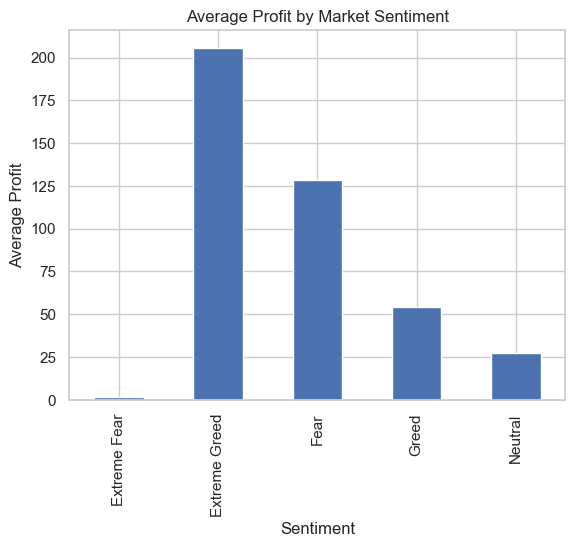

In [49]:
plt.figure()
merged_df.groupby('classification')['closed_pnl'].mean().plot(kind='bar')

plt.title("Average Profit by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Profit")

plt.savefig("../outputs/charts/profit_vs_sentiment.png")
plt.show()

In [51]:
# Re-create feature
merged_df['is_profit'] = merged_df['closed_pnl'] > 0

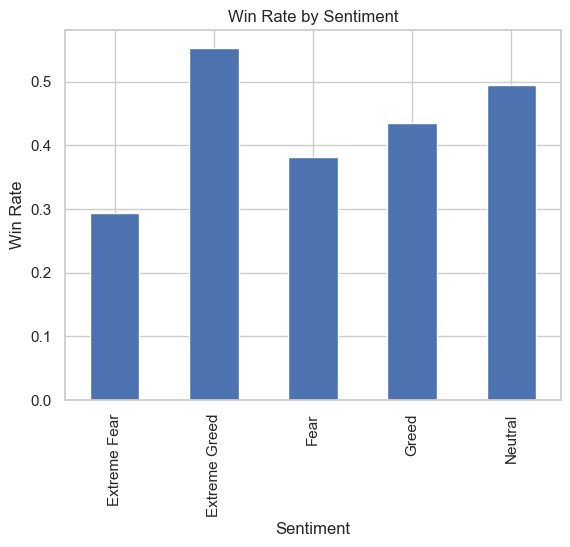

In [52]:
merged_df.groupby('classification')['is_profit'].mean().plot(kind='bar')

plt.title("Win Rate by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")

plt.savefig("../outputs/charts/winrate_vs_sentiment.png")
plt.show()

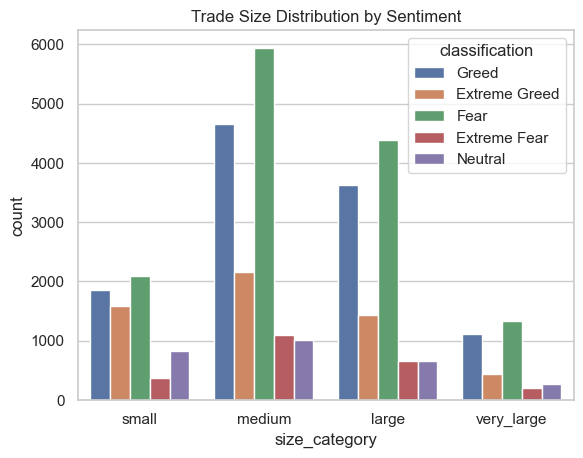

In [55]:
import seaborn as sns

plt.figure()
sns.countplot(data=merged_df, x='size_category', hue='classification')

plt.title("Trade Size Distribution by Sentiment")
plt.savefig("../outputs/charts/trade_size_distribution.png")
plt.show()

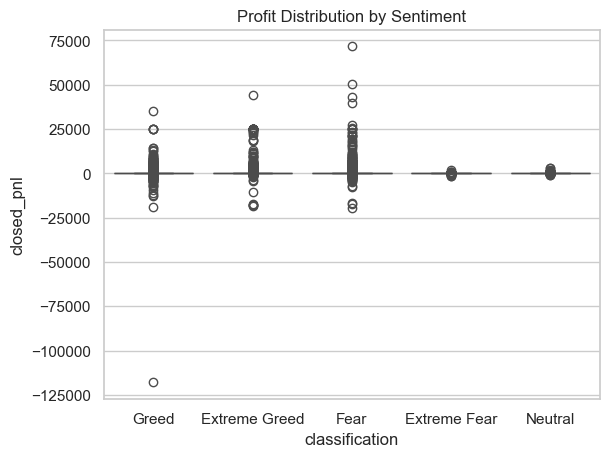

In [56]:
plt.figure()
sns.boxplot(data=merged_df, x='classification', y='closed_pnl')

plt.title("Profit Distribution by Sentiment")
plt.savefig("../outputs/charts/profit_distribution.png")
plt.show()

## 📊 Visualization Insights

- Profit varies significantly across Fear and Greed conditions
- Win rate differences indicate behavioral bias in trading
- Larger trades are more common during Greed phases
- Profit distribution shows higher volatility during Greed markets